# Notebook 05 — Model Pipelines & Training
### Credit Risk — PD Scorecard | Stages 6 + 8

---

## What this notebook does

Trains **six models**, each with its own preprocessing pipeline (blueprint
Section 4 — different models have different requirements), on the **frozen
split from notebook 04**, then tunes XGBoost with Optuna using
**cross-validation inside the objective** so the test set is never touched
during tuning.

| Step | LR | DT | RF | XGBoost | LightGBM | HistGB |
|---|---|---|---|---|---|---|
| Imputation | median | explicit median* | explicit median* | native NaN | native NaN | native NaN |
| Scaling | standard | – | – | – | – | – |
| Encoding | one-hot | label | label | label | label | label |
| Imbalance | class_weight | class_weight | class_weight | scale_pos_weight | scale_pos_weight | class_weight |

*chosen deliberately over sklearn's silent native handling — see §5.4.

**Two models added beyond the blueprint's four**, with reasoning:
- **LightGBM** — the other industry-standard gradient booster and XGBoost's
  main rival (heavily used by the winning solutions for this competition).
  Comparing the two strengthens the final model choice.
- **HistGradientBoosting** — scikit-learn's own native boosting (LightGBM-style
  histogram algorithm), zero extra dependency. A useful sanity check that the
  boosting advantage is real and not library-specific.

**Inputs:** `features_selected_general.csv`, `features_selected_lr.csv`,
`train_test_split_ids.csv` &nbsp;|&nbsp; **Outputs:** fitted models in
`outputs/models/`, `model_predictions.csv` for Stage 9.

## Leakage discipline in this notebook

1. The split is **loaded, not created** — the same frozen 80/20 used for
   feature selection.
2. Every imputer / scaler / encoder is **fit on training rows only**.
3. Optuna's objective scores by **3-fold CV on the training set** — the test
   set is evaluated exactly once per model, at the end.
   (An earlier version of this project tuned against the test set directly —
   a flaw found and fixed; the CV design below is the fix.)

## Train/test split — methodology note (kept from the original investigation)

The blueprint planned a time-based split on `DAYS_DECISION`. Investigation
showed that column exists only in `previous_application` (past loans) —
`application_train` has **no native time column**, so no genuine out-of-time
split is possible. Verified against public practice for this dataset: random
stratified splitting is standard (the competition itself is evaluated that
way). Consequence acknowledged: evaluation assumes the future resembles the
past population; in production, out-of-time validation would be mandatory.

> Run from project root, top to bottom. Requires `utils.py` in the project
> root. **The Optuna cell is the slow one** (30 trials × 3 folds — expect
> roughly 30–90 minutes depending on the machine).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import optuna

import utils
from utils import (DATA_PATH, C_RED, C_BLUE, C_GREEN, C_GREY,
                   RANDOM_STATE, save_show, is_text_column)
utils.setup()
os.makedirs("outputs/models", exist_ok=True)

df_general = pd.read_csv(DATA_PATH + "features_selected_general.csv")
df_lr      = pd.read_csv(DATA_PATH + "features_selected_lr.csv")
split_ids  = pd.read_csv(DATA_PATH + "train_test_split_ids.csv")
print(f"General: {df_general.shape} | LR: {df_lr.shape} | split ids: {split_ids.shape}")

/opt/anaconda3/envs/credit_risk/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


General: (307511, 45) | LR: (307511, 41) | split ids: (307511, 2)


## 5.1 Load the frozen split (never re-split)

In [3]:
for d in (df_general, df_lr):
    assert (d['SK_ID_CURR'].values == split_ids['SK_ID_CURR'].values).all(), \
        "Row order mismatch vs split file - re-run notebook 04"

train_mask = (split_ids['SPLIT'] == 'train').values
test_mask  = ~train_mask

y       = df_general['TARGET']
y_train, y_test = y[train_mask], y[test_mask]

X_general = df_general.drop(columns=['TARGET', 'SK_ID_CURR'])
X_lr      = df_lr.drop(columns=['TARGET', 'SK_ID_CURR'])

X_train_gen, X_test_gen = X_general[train_mask], X_general[test_mask]
X_train_lr,  X_test_lr  = X_lr[train_mask],      X_lr[test_mask]

print(f"Train {X_train_gen.shape} ({y_train.mean()*100:.2f}% default) | "
      f"Test {X_test_gen.shape} ({y_test.mean()*100:.2f}% default)")

Train (246008, 43) (8.07% default) | Test (61503, 43) (8.07% default)


## 5.2 Model 1 — Logistic Regression (interpretable baseline)

Needs everything: median imputation (can't handle NaN; median because of
right-skew), standard scaling (regularisation and solver are scale-sensitive),
one-hot encoding (would read label codes as ordered magnitudes). Uses the
41-column VIF-reduced set so coefficients stay stable — this model's job is
interpretability and the future scorecard, not the top score.

In [4]:
categorical_cols_lr = [c for c in X_train_lr.columns if is_text_column(X_train_lr[c])]
numeric_cols_lr     = [c for c in X_train_lr.columns if c not in categorical_cols_lr]
print(f"LR set: {len(numeric_cols_lr)} numeric + {len(categorical_cols_lr)} categorical")

preprocessor_lr = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler', StandardScaler())]), numeric_cols_lr),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols_lr),
])

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000,
                                      random_state=RANDOM_STATE)),
])
lr_pipeline.fit(X_train_lr, y_train)

y_pred_lr = lr_pipeline.predict_proba(X_test_lr)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr)
print(f"Logistic Regression - Test AUC: {auc_lr:.4f}")

LR set: 33 numeric + 6 categorical
Logistic Regression - Test AUC: 0.7571


## 5.3 Shared preparation for tree models — label encoding

Trees split on thresholds, so integer category codes are fine (a tree can
carve them apart with multiple splits). Encoders are **fit on train only**;
unseen test categories map to an explicit `Unknown` code.

In [5]:
categorical_cols_gen = [c for c in X_train_gen.columns if is_text_column(X_train_gen[c])]

X_train_gen_encoded = X_train_gen.copy()
X_test_gen_encoded  = X_test_gen.copy()
label_encoders = {}

for col in categorical_cols_gen:
    le = LabelEncoder()
    X_train_gen_encoded[col] = le.fit_transform(X_train_gen[col].astype(str))
    known = set(le.classes_)
    if 'Unknown' not in known:
        le.classes_ = np.append(le.classes_, 'Unknown')
    X_test_gen_encoded[col] = le.transform(
        X_test_gen[col].astype(str).where(X_test_gen[col].astype(str).isin(known), 'Unknown'))
    label_encoders[col] = le

joblib.dump(label_encoders, "outputs/models/label_encoders.pkl")   # reused by notebook 07
print(f"Label-encoded {len(categorical_cols_gen)} columns (train-fit, saved for reuse).")

Label-encoded 6 columns (train-fit, saved for reuse).


###### 5.4 Model 2 — Decision Tree, and the silent-NaN discovery

The blueprint says trees need no imputation. First fit ran on data still
containing **665,570 NaN** — and sklearn raised no error, contradicting its
older documented behaviour. Root cause: **sklearn ≥1.4 handles missing values
natively in tree estimators**. Rather than rely on a silent, version-specific
default, both versions are compared and the **explicit** one is chosen — so
behaviour is documented and reproducible across library versions.

In [6]:
import sklearn
print(f"sklearn {sklearn.__version__} | NaN in encoded train: "
      f"{X_train_gen_encoded.isnull().sum().sum():,}")

# (a) native NaN handling
dt_native = DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                                   random_state=RANDOM_STATE)
dt_native.fit(X_train_gen_encoded, y_train)
auc_dt_native = roc_auc_score(y_test, dt_native.predict_proba(X_test_gen_encoded)[:, 1])

# (b) explicit median imputation (fit on train only)
imputer_tree = SimpleImputer(strategy='median')
X_train_gen_imputed = pd.DataFrame(imputer_tree.fit_transform(X_train_gen_encoded),
                                   columns=X_train_gen_encoded.columns)
X_test_gen_imputed  = pd.DataFrame(imputer_tree.transform(X_test_gen_encoded),
                                   columns=X_test_gen_encoded.columns)

dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                                  random_state=RANDOM_STATE)
dt_model.fit(X_train_gen_imputed, y_train)
y_pred_dt = dt_model.predict_proba(X_test_gen_imputed)[:, 1]
auc_dt = roc_auc_score(y_test, y_pred_dt)

print(f"DT native NaN handling : {auc_dt_native:.4f}")
print(f"DT explicit imputation : {auc_dt:.4f}  <- kept (documented, version-stable)")

sklearn 1.9.0 | NaN in encoded train: 665,570
DT native NaN handling : 0.7295
DT explicit imputation : 0.7314  <- kept (documented, version-stable)


## 5.5 Model 3 — Random Forest

Bagging: 200 bootstrap trees, random feature subsets per split, averaged —
variance reduction over the single tree. Same imputed/encoded matrix.

In [7]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10,
                                  class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_gen_imputed, y_train)
y_pred_rf = rf_model.predict_proba(X_test_gen_imputed)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_rf)
print(f"Random Forest - Test AUC: {auc_rf:.4f}")

Random Forest - Test AUC: 0.7566


## 5.6 Model 4 — XGBoost (baseline, before tuning)

Gradient boosting: shallow trees fit sequentially on the loss gradient.
Handles NaN natively by learning a per-node default direction — so it gets the
**encoded but non-imputed** matrix. Imbalance via
`scale_pos_weight = n_negative / n_positive`.

In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_base = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                             scale_pos_weight=scale_pos_weight,
                             random_state=RANDOM_STATE, eval_metric='auc', n_jobs=-1)
xgb_base.fit(X_train_gen_encoded, y_train)
auc_xgb_base = roc_auc_score(y_test, xgb_base.predict_proba(X_test_gen_encoded)[:, 1])
print(f"XGBoost (baseline) - Test AUC: {auc_xgb_base:.4f}")

scale_pos_weight: 11.39
XGBoost (baseline) - Test AUC: 0.7771


## 5.7 Model 5 — LightGBM *(added)*

The other industry-standard booster: leaf-wise growth + histogram binning,
typically faster than XGBoost at similar accuracy, and the workhorse of the
winning solutions for this exact competition. Native NaN handling; same
encoded matrix and `scale_pos_weight`.

In [9]:
lgb_model = lgb.LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.05,
                               scale_pos_weight=scale_pos_weight,
                               random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
lgb_model.fit(X_train_gen_encoded, y_train)
y_pred_lgb = lgb_model.predict_proba(X_test_gen_encoded)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)
print(f"LightGBM - Test AUC: {auc_lgb:.4f}")

LightGBM - Test AUC: 0.7781


## 5.8 Model 6 — HistGradientBoosting *(added)*

scikit-learn's own histogram-based booster (LightGBM-inspired), zero extra
dependency. If boosting's advantage is real, it should appear here too —
a library-independence sanity check on the XGBoost/LightGBM results.

In [10]:
hgb_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                           class_weight='balanced',
                                           random_state=RANDOM_STATE)
hgb_model.fit(X_train_gen_encoded, y_train)
y_pred_hgb = hgb_model.predict_proba(X_test_gen_encoded)[:, 1]
auc_hgb = roc_auc_score(y_test, y_pred_hgb)
print(f"HistGradientBoosting - Test AUC: {auc_hgb:.4f}")

HistGradientBoosting - Test AUC: 0.7777


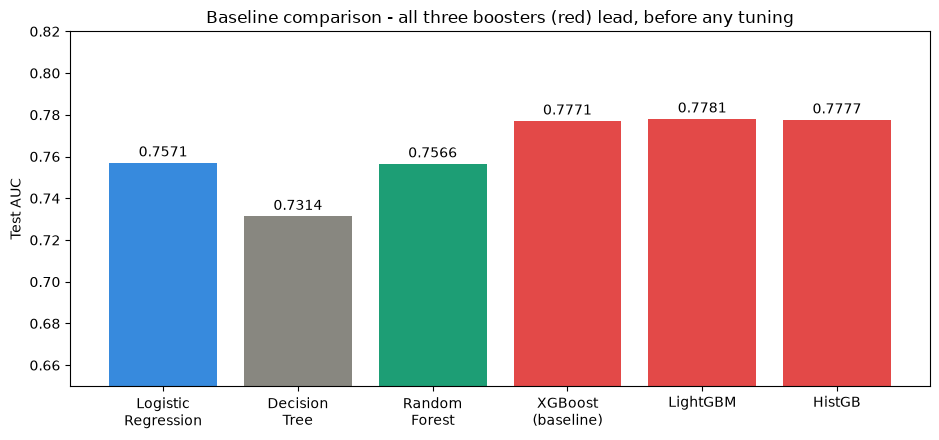

In [11]:
names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest',
         'XGBoost\n(baseline)', 'LightGBM', 'HistGB']
aucs  = [auc_lr, auc_dt, auc_rf, auc_xgb_base, auc_lgb, auc_hgb]
cols  = [C_BLUE, C_GREY, C_GREEN, C_RED, C_RED, C_RED]

fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars = ax.bar(names, aucs, color=cols)
for b, v in zip(bars, aucs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.4f}", ha='center', fontsize=10)
ax.set_ylim(0.65, 0.82); ax.set_ylabel('Test AUC')
ax.set_title('Baseline comparison - all three boosters (red) lead, before any tuning')
save_show("05_baseline_comparison.png")

## 5.9 Bayesian tuning — XGBoost, the leakage-safe way

**Design (the fix):** the objective scores each trial by **3-fold stratified
cross-validation on training data only**. The sampler is seeded so re-runs
reproduce identical trials. After the search, the best configuration is refit
on the full training set and the test set is scored **once**.

*(The earlier version of this project scored trials directly on the test set —
meaning hyperparameters were selected against the data used for the final
report. Small practical effect at 30 trials, but methodologically wrong;
this cell is the corrected design.)*

In [12]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
Xt = X_train_gen_encoded.reset_index(drop=True)
yt = y_train.reset_index(drop=True)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': scale_pos_weight,
        'random_state': RANDOM_STATE, 'eval_metric': 'auc', 'n_jobs': -1,
    }
    fold_aucs = []
    for tr_idx, va_idx in cv.split(Xt, yt):
        model = xgb.XGBClassifier(**params)
        model.fit(Xt.iloc[tr_idx], yt.iloc[tr_idx])
        fold_aucs.append(roc_auc_score(yt.iloc[va_idx],
                                       model.predict_proba(Xt.iloc[va_idx])[:, 1]))
    return float(np.mean(fold_aucs))          # CV score - test set never touched

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best CV AUC : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

[I 2026-07-11 09:25:28,337] A new study created in memory with name: no-name-4b1c0503-df29-436d-9e52-97407566f511
Best trial: 0. Best value: 0.730455:   3%|▌                 | 1/30 [00:07<03:35,  7.44s/it]

[I 2026-07-11 09:25:35,777] Trial 0 finished with value: 0.730454899976546 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.730454899976546.


Best trial: 1. Best value: 0.745875:   7%|█▏                | 2/30 [00:15<03:33,  7.62s/it]

[I 2026-07-11 09:25:43,530] Trial 1 finished with value: 0.7458748317529835 and parameters: {'n_estimators': 447, 'max_depth': 7, 'learning_rate': 0.11114989443094977, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'gamma': 1.0616955533913808}. Best is trial 1 with value: 0.7458748317529835.


Best trial: 2. Best value: 0.761978:  10%|█▊                | 3/30 [00:17<02:19,  5.18s/it]

...

[I 2026-07-11 09:27:53,959] Trial 27 finished with value: 0.7424442149870777 and parameters: {'n_estimators': 436, 'max_depth': 7, 'learning_rate': 0.13885697084667312, 'subsample': 0.8989091907917381, 'colsample_bytree': 0.8103011446260465, 'min_child_weight': 4, 'gamma': 2.3385526505484124}. Best is trial 17 with value: 0.773616718509862.


Best trial: 17. Best value: 0.773617:  97%|███████████████▍| 29/30 [02:34<00:08,  8.04s/it]

[I 2026-07-11 09:28:03,119] Trial 28 finished with value: 0.770569794064441 and parameters: {'n_estimators': 466, 'max_depth': 6, 'learning_rate': 0.015883288290392254, 'subsample': 0.9550596038682698, 'colsample_bytree': 0.6800339710095507, 'min_child_weight': 3, 'gamma': 0.6940720754287557}. Best is trial 17 with value: 0.773616718509862.


Best trial: 17. Best value: 0.773617: 100%|████████████████| 30/30 [02:39<00:00,  5.30s/it]

[I 2026-07-11 09:28:07,460] Trial 29 finished with value: 0.7730058262515791 and parameters: {'n_estimators': 315, 'max_depth': 4, 'learning_rate': 0.11512581457778419, 'subsample': 0.8426108345760126, 'colsample_bytree': 0.6348935038302269, 'min_child_weight': 7, 'gamma': 0.36808238983442776}. Best is trial 17 with value: 0.773616718509862.
Best CV AUC : 0.7736
Best params : {'n_estimators': 408, 'max_depth': 4, 'learning_rate': 0.08350570497622349, 'subsample': 0.7712024473934024, 'colsample_bytree': 0.6547235997514183, 'min_child_weight': 6, 'gamma': 2.0850736746159972}


In [13]:
best_params = dict(study.best_params)
best_params.update({'scale_pos_weight': scale_pos_weight, 'random_state': RANDOM_STATE,
                    'eval_metric': 'auc', 'n_jobs': -1})

xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(X_train_gen_encoded, y_train)      # refit on FULL training set

y_pred_xgb = xgb_tuned.predict_proba(X_test_gen_encoded)[:, 1]
auc_xgb_tuned = roc_auc_score(y_test, y_pred_xgb)   # the single test-set touch
print(f"Tuned XGBoost - Test AUC: {auc_xgb_tuned:.4f} "
      f"(baseline was {auc_xgb_base:.4f})")

Tuned XGBoost - Test AUC: 0.7797 (baseline was 0.7771)


## 5.10 Save everything for Stages 9–10

In [14]:
joblib.dump(lr_pipeline, "outputs/models/lr_pipeline.pkl")
joblib.dump(dt_model,    "outputs/models/dt_model.pkl")
joblib.dump(rf_model,    "outputs/models/rf_model.pkl")
joblib.dump(xgb_tuned,   "outputs/models/xgb_tuned.pkl")
joblib.dump(lgb_model,   "outputs/models/lgb_model.pkl")
joblib.dump(hgb_model,   "outputs/models/hgb_model.pkl")
joblib.dump(imputer_tree, "outputs/models/imputer_tree.pkl")

predictions_df = pd.DataFrame({
    'SK_ID_CURR': df_general.loc[test_mask, 'SK_ID_CURR'].values,
    'y_true':   y_test.values,
    'lr_pred':  y_pred_lr,
    'dt_pred':  y_pred_dt,
    'rf_pred':  y_pred_rf,
    'xgb_pred': y_pred_xgb,
    'lgb_pred': y_pred_lgb,
    'hgb_pred': y_pred_hgb,
})
predictions_df.to_csv(DATA_PATH + "model_predictions.csv", index=False)
print(f"6 models + encoders + imputer saved | predictions: {predictions_df.shape}")

6 models + encoders + imputer saved | predictions: (61503, 8)


---
# Summary

Six models, six pipelines, one frozen split. Leakage-safe by construction:
train-only preprocessing fits, CV-based tuning, one test-set touch per model.
The three gradient boosters should cluster at the top (library-independent
confirmation that boosting suits this data); Logistic Regression stays the
interpretable, scorecard-ready baseline.

Two earlier flaws are now fixed in this notebook: the test-set Optuna
objective (replaced by 3-fold CV) and the unseeded sampler (TPE now seeded —
re-runs reproduce identical trials).

## Next: Notebook 06 — evaluation
KS statistic (primary), AUC/Gini, recall, Brier, calibration curves, and
train-vs-test overfitting checks — now across all six models.